# Modelo de Classificação de Vulnerabilidade Financeira — SVM

**Objetivo:** Classificar o perfil de vulnerabilidade financeira de indivíduos.

**Algoritmo:** Support Vector Machine (SVM) com kernel RBF

**Base de comparação:** modelo_vulnerabilidade-->Random Forest (AUC: 0.9724, Recall: 80%)

Por que SVM? Perspectiva diferente das árvores: busca o hiperplano de margem máxima para separar as classes. Com kernel RBF captura fronteiras não-lineares.

In [25]:



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')


## 1. Carregamento e Verificação dos Dados

Mesmo dataset: 20.000 clientes, 27 colunas.
Verificamos nulos antes de qualquer processamento.

In [26]:
df = pd.read_parquet('../../dataset/data.parquet')
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")


Linhas: 20000 | Colunas: 27


In [27]:
df.isnull().sum()

Income                             0
Age                                0
Dependents                         0
Occupation                         0
City_Tier                          0
Rent                               0
Loan_Repayment                     0
Insurance                          0
Groceries                          0
Transport                          0
Eating_Out                         0
Entertainment                      0
Utilities                          0
Healthcare                         0
Education                          0
Miscellaneous                      0
Desired_Savings_Percentage         0
Desired_Savings                    0
Disposable_Income                  0
Potential_Savings_Groceries        0
Potential_Savings_Transport        0
Potential_Savings_Eating_Out       0
Potential_Savings_Entertainment    0
Potential_Savings_Utilities        0
Potential_Savings_Healthcare       0
Potential_Savings_Education        0
Potential_Savings_Miscellaneous    0
d

In [28]:
df[['Income', 'Disposable_Income', 'Desired_Savings', 'Loan_Repayment']].describe()


,Income,Disposable_Income,Desired_Savings,Loan_Repayment
count,2.000000e+04,20000.000000,20000.000000,20000.000000
mean,4.158550e+04,10647.367257,4982.878416,2049.800292
std,4.001454e+04,11740.637289,7733.468188,4281.789941
min,1.301187e+03,-5400.788673,0.000000,0.000000
25%,1.760488e+04,3774.894323,1224.932636,0.000000
50%,3.018538e+04,7224.890977,2155.356763,0.000000
75%,5.176545e+04,13331.950716,6216.309609,2627.142320
max,1.079728e+06,377060.218482,245504.485208,123080.682009


In [29]:
(df['Desired_Savings'] == 0).sum()


np.int64(112)

In [30]:
df = df[df['Desired_Savings'] > 0]
print(f"Dataset após remoção: {len(df):,} clientes")


Dataset após remoção: 19,888 clientes


## 2. Engenharia de Features

Criamos métricas percentuais para comparar clientes com rendas diferentes de forma justa.
Mesmas features usadas pelo João para construir o target.

In [31]:
colunas_potencial = [
    'Potential_Savings_Groceries',
    'Potential_Savings_Transport',
    'Potential_Savings_Eating_Out',
    'Potential_Savings_Entertainment',
    'Potential_Savings_Utilities',
    'Potential_Savings_Healthcare',
    'Potential_Savings_Education',
    'Potential_Savings_Miscellaneous'
]

df['perc_emprestimo'] = df['Loan_Repayment'] / df['Income']
df['perc_nao_essenciais'] = (df['Eating_Out'] + df['Entertainment']) / df['Income']
df['total_potential_savings'] = df[colunas_potencial].sum(axis=1)
df['perc_potential_savings'] = df['total_potential_savings'] / df['Income']
df['buffer_emergencia'] = (df['Disposable_Income'] - df['Desired_Savings']) / df['Income']

print("Features criadas com sucesso!")


Features criadas com sucesso!


## 3. Definição do Target

Cliente é vulnerável se atender 2 ou mais das 4 condições:

- c1: Empréstimo > 10% da renda
- c2: Gastos não essenciais > 8,5% da renda
- c3: Buffer de emergência < 10% da renda
- c4: Economia potencial desperdiçada > 8% da renda

Dataset desbalanceado: 77% Seguros vs 23% Vulneráveis, tratado com class_weight=balanced.

Condicoes para alguem ser classificado como vulneravel

1 = positivo = tem a característica que queremos detectar = Vulnerável
0 = negativo = não tem a característica = Seguro

In [32]:
c1 = (df['perc_emprestimo'] > 0.10).astype(int)
c2 = (df['perc_nao_essenciais'] > 0.085).astype(int)
c3 = (df['buffer_emergencia'] < 0.10).astype(int)
c4 = (df['perc_potential_savings'] > 0.08).astype(int)

df['risk_score'] = c1 + c2 + c3 + c4
df['Vulnerable'] = (df['risk_score'] >= 2).astype(int)

print("Distribuição do target:")
print(df['Vulnerable'].value_counts())


Distribuição do target:
Vulnerable
0    15357
1     4531
Name: count, dtype: int64


In [33]:
df.groupby('Vulnerable')[['Income', 'perc_emprestimo', 'perc_nao_essenciais', 'buffer_emergencia', 'perc_potential_savings']].mean().round(4)


,Income,perc_emprestimo,perc_nao_essenciais,buffer_emergencia,perc_potential_savings
Vulnerable,,,,,
0,39739.8395,0.0246,0.0688,0.1953,0.0610
1,47741.3189,0.1322,0.0739,0.0490,0.0655


A grande conclusão: o maior diferenciador é o perc_emprestimo e o buffer_emergencia. Quem é vulnerável está afogado em empréstimos e não tem margem de segurança, independente de ganhar mais.

## 4. Preparação do Modelo

A correlação revelou redundância alta (>0.90) entre Income, Eating_Out, Entertainment e Healthcare.
Reduzimos para 11 featuresmesma decisão do modelo anteriormente criado.

Divisão 80/20 com stratify=y para manter proporção de vulneráveis em treino e teste.

StandardScaler é obrigatório para o SVM: ele calcula distâncias e sem normalização Income dominaria Age completamente.

In [34]:
df['savings_rate'] = df['Desired_Savings'] / df['Income']

features = [
    'Income', 'Age', 'Dependents', 'Loan_Repayment', 'Eating_Out',
    'Entertainment', 'Healthcare', 'savings_rate', 'perc_emprestimo',
    'perc_nao_essenciais', 'buffer_emergencia', 'perc_potential_savings'
]

X = df[features]
y = df['Vulnerable']


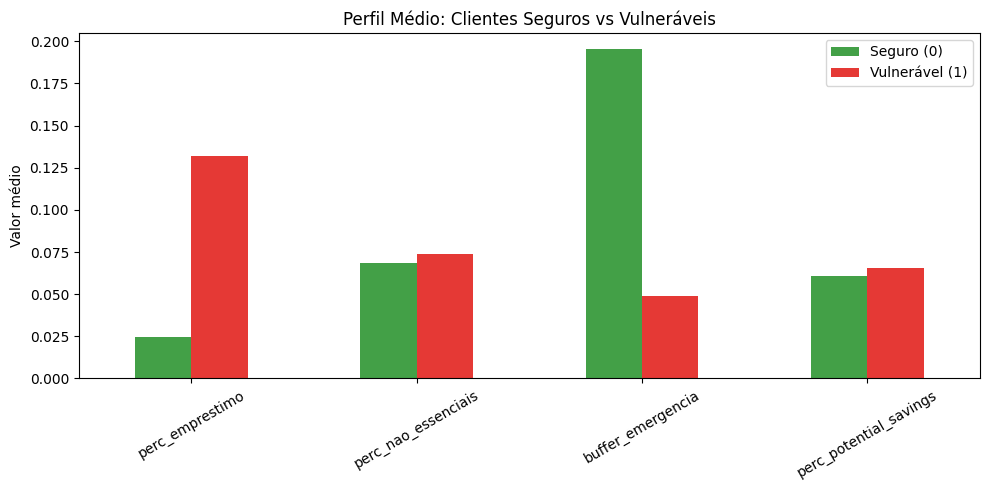

In [35]:
grupos = df.groupby('Vulnerable')[['perc_emprestimo', 'perc_nao_essenciais', 'buffer_emergencia', 'perc_potential_savings']].mean()

grupos.T.plot(kind='bar', figsize=(10, 5), color=['#43a047', '#e53935'])
plt.title('Perfil Médio: Clientes Seguros vs Vulneráveis')
plt.ylabel('Valor médio')
plt.xticks(rotation=30)
plt.legend(['Seguro (0)', 'Vulnerável (1)'])
plt.tight_layout()
plt.savefig('comparativo_grupos.png', dpi=150)
plt.show()


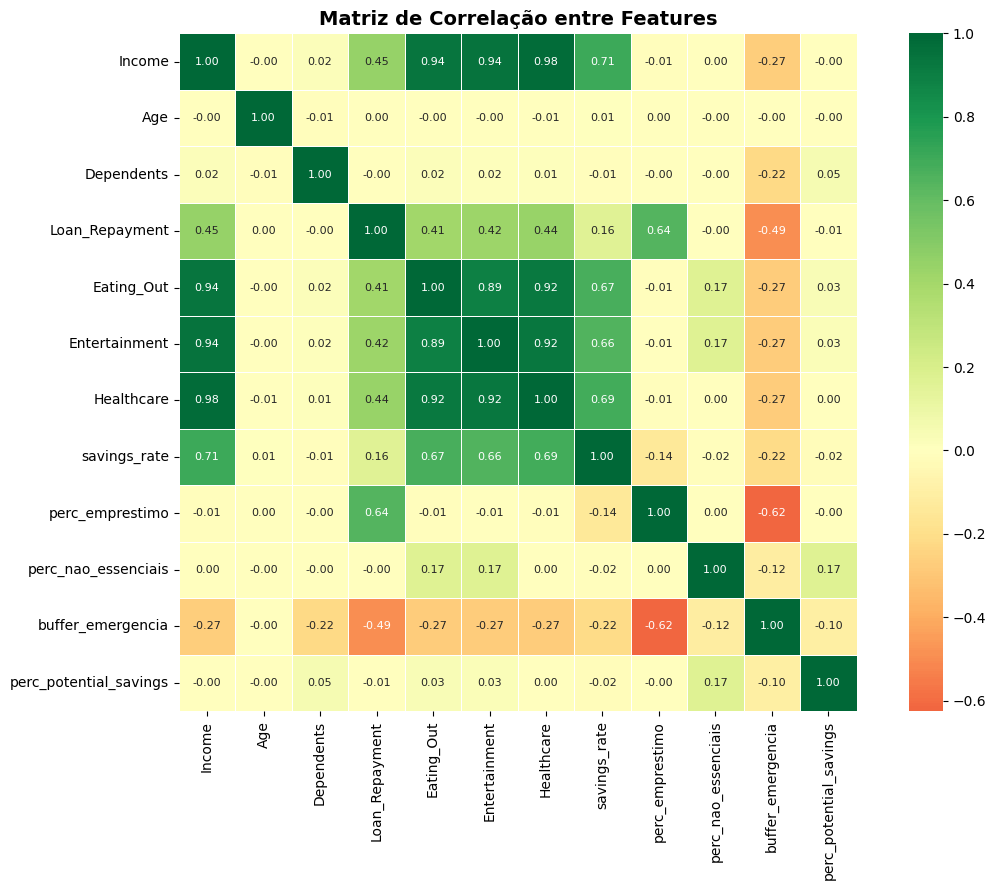


Pares com correlação alta (> 0.7 ou < -0.7):
  Eating_Out ↔ Income: 0.94
  Entertainment ↔ Income: 0.94
  Healthcare ↔ Income: 0.98
  savings_rate ↔ Income: 0.71
  Income ↔ Eating_Out: 0.94
  Entertainment ↔ Eating_Out: 0.89
  Healthcare ↔ Eating_Out: 0.92
  Income ↔ Entertainment: 0.94
  Eating_Out ↔ Entertainment: 0.89
  Healthcare ↔ Entertainment: 0.92
  Income ↔ Healthcare: 0.98
  Eating_Out ↔ Healthcare: 0.92
  Entertainment ↔ Healthcare: 0.92
  Income ↔ savings_rate: 0.71


In [36]:
%matplotlib inline

corr_matrix = X.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, annot_kws={"size": 8})
plt.title('Matriz de Correlação entre Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacao_features.png', dpi=150)
plt.show()

print("\nPares com correlação alta (> 0.7 ou < -0.7):")
for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if col != row and abs(corr_matrix.loc[row, col]) > 0.7:
            print(f"  {row} ↔ {col}: {corr_matrix.loc[row, col]:.2f}")


In [37]:
features_reduzidas = [
    'Income', 'Age', 'Dependents', 'Loan_Repayment',
    'Eating_Out', 'Entertainment', 'Healthcare',
    'Rent', 'Groceries', 'Disposable_Income', 'Desired_Savings'
]

X = df[features_reduzidas]
y = df['Vulnerable']

print(f"Features anteriores: 12")
print(f"Features após redução: {X.shape[1]}")
print(f"\nFeatures mantidas: {features_reduzidas}")


Features anteriores: 12
Features após redução: 11

Features mantidas: ['Income', 'Age', 'Dependents', 'Loan_Repayment', 'Eating_Out', 'Entertainment', 'Healthcare', 'Rent', 'Groceries', 'Disposable_Income', 'Desired_Savings']


separando entre dados treinados e teste

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino:  {X_train.shape[0]} clientes")
print(f"Teste:   {X_test.shape[0]} clientes")


Treino:  15910 clientes
Teste:   3978 clientes


O StandardScaler transforma cada feature para ter média 0 e desvio padrão 1

In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Normalização concluída!")


Normalização concluída!


treinando o svm

In [40]:
import time

svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)

inicio = time.time()
svm.fit(X_train_scaled, y_train)
fim = time.time()

print(f" SVM treinado em {fim - inicio:.1f} segundos")
print(f"   Vetores de suporte: {svm.n_support_}")
print(f"   Total de vetores de suporte: {sum(svm.n_support_)}")


KeyboardInterrupt: 

Com probability=True ele passa a dizer "tem 73% de chance de ser vulnerável" — uma probabilidade.

Precisamos disso para:

Calcular o AUC-ROC (que usa probabilidades, não só a classificação final)
Fazer a segmentação de risco em Baixo/Médio/Alto no final
O lado negativo: deixa o treino mais lento porque usa um processo extra chamado calibração de Platt internamente.

In [ ]:
y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]
auc_svm = roc_auc_score(y_test, y_prob_svm)

print(f"{'='*50}")
print(f"  SVM (RBF) — AUC-ROC: {auc_svm:.4f}")
print(f"{'='*50}")
print(classification_report(y_test, y_pred_svm, target_names=['Seguro', 'Vulnerável']))


  SVM (RBF) — AUC-ROC: 0.9658
              precision    recall  f1-score   support

      Seguro       0.97      0.91      0.94      3072
  Vulnerável       0.74      0.91      0.81       906

    accuracy                           0.91      3978
   macro avg       0.85      0.91      0.88      3978
weighted avg       0.92      0.91      0.91      3978



## 5. Treinamento e Avaliação do SVM

Parâmetros: kernel=rbf, class_weight=balanced, probability=True

Comparação com Random Forest do outro modelo:

| Métrica | Random Forest (primeiro modelo) | SVM (este notebook) |
|---|---|---|
| AUC-ROC | 0.9724 | 0.9658 |
| Acurácia | 94% | 91% |
| Precision (Vuln.) | 92% | 74% |
| **Recall (Vuln.)** | **80%** | **91%** |
| F1 (Vuln.) | 85% | 81% |

O SVM detecta mais vulneráveis reais ao custo de mais falsos positivos. Para este problema isso é mais adequado.

## 6. Matriz de Confusão

Comparação com Random Forest do outro modelo:

| Resultado | RF João | SVM |
|---|---|---|
| Verdadeiros Positivos | 722 | **822** |
| Falsos Negativos | 184 | **84** |
| Falsos Positivos | 61 | 290 |

O SVM identificou 100 vulneráveis a mais. Gera mais falsos positivos, mas este é o erro menos grave no contexto financeiro.

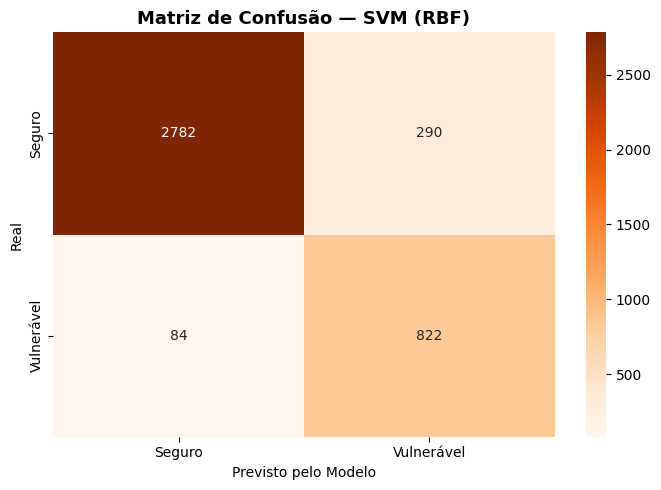


Verdadeiros Negativos (Seguro → Seguro):        2782
Falsos Positivos    (Seguro → Vulnerável):       290
Falsos Negativos    (Vulnerável → Seguro):       84
Verdadeiros Positivos (Vulnerável → Vulnerável): 822

De 906 vulneráveis reais, o modelo identificou 822 corretamente (90.7%)


In [ ]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Seguro', 'Vulnerável'],
            yticklabels=['Seguro', 'Vulnerável'])
plt.title('Matriz de Confusão — SVM (RBF)', fontsize=13, fontweight='bold')
plt.ylabel('Real')
plt.xlabel('Previsto pelo Modelo')
plt.tight_layout()
plt.savefig('confusion_matrix_svm.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nVerdadeiros Negativos (Seguro → Seguro):        {tn}")
print(f"Falsos Positivos    (Seguro → Vulnerável):       {fp}")
print(f"Falsos Negativos    (Vulnerável → Seguro):       {fn}")
print(f"Verdadeiros Positivos (Vulnerável → Vulnerável): {tp}")
print(f"\nDe {tp+fn} vulneráveis reais, o modelo identificou {tp} corretamente ({tp/(tp+fn)*100:.1f}%)")


confusion_matrix(y_test, y_pred_svm) — compara o que era real (y_test) com o que o modelo previu (y_pred_svm) e monta uma tabela 2x2 com os 4 tipos de resultado.

sns.heatmap(...) — transforma essa tabela 2x2 em um gráfico colorido para visualizar facilmente onde o modelo acertou e errou.

cm.ravel() — "abre" a matriz 2x2 em 4 números na ordem: tn, fp, fn, tp. É só uma forma de extrair os valores individualmente.

Os 4 valores:

tn (2782) — modelo disse Seguro, era Seguro ✅
fp (290) — modelo disse Vulnerável, era Seguro ❌
fn (84) — modelo disse Seguro, era Vulnerável ❌
tp (822) — modelo disse Vulnerável, era Vulnerável ✅
A última linha calcula o Recall manualmente: 822 / (822 + 84) = 90.7%.

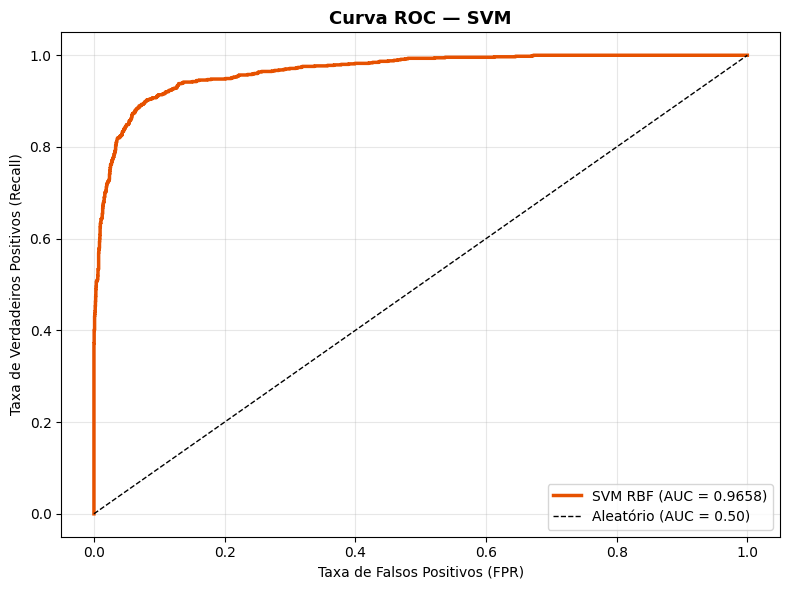

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e65100', linewidth=2.5,
         label=f'SVM RBF (AUC = {auc_svm:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório (AUC = 0.50)')

plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
plt.title('Curva ROC — SVM', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_svm.png', dpi=150)
plt.show()


Quanto mais a curva do SVM (laranja) estiver acima e à esquerda dessa linha pontilhada, melhor o modelo é em relação ao acaso.

O nosso SVM tem AUC = 0.9658 — muito acima da diagonal. Isso significa que ele é muito melhor do que chutar aleatoriamente.

## 7. Importância das Features

Usamos Permutation Importance pois o SVM não possui feature_importances_ nativo.

Comparação com SHAP do outro modelo:

| Feature | RF-João | SVM |
|---|---|---|
| Loan_Repayment | 1º | 2º |
| Disposable_Income | 2º | **1º** |
| Eating_Out | 4º | 3º |

Ambos concordam nas features mais importantes. Diferença: João via peso do empréstimo; SVM vê a margem disponível.

          feature  importancia      std
Disposable_Income     0.330138 0.007069
   Loan_Repayment     0.127302 0.002909
       Eating_Out     0.093812 0.003751
    Entertainment     0.090965 0.004870
  Desired_Savings     0.060220 0.002664
           Income     0.055069 0.002240
             Rent     0.013355 0.001037
       Healthcare     0.009579 0.000962
        Groceries     0.007580 0.001269
       Dependents     0.001336 0.000321
              Age     0.000883 0.000244


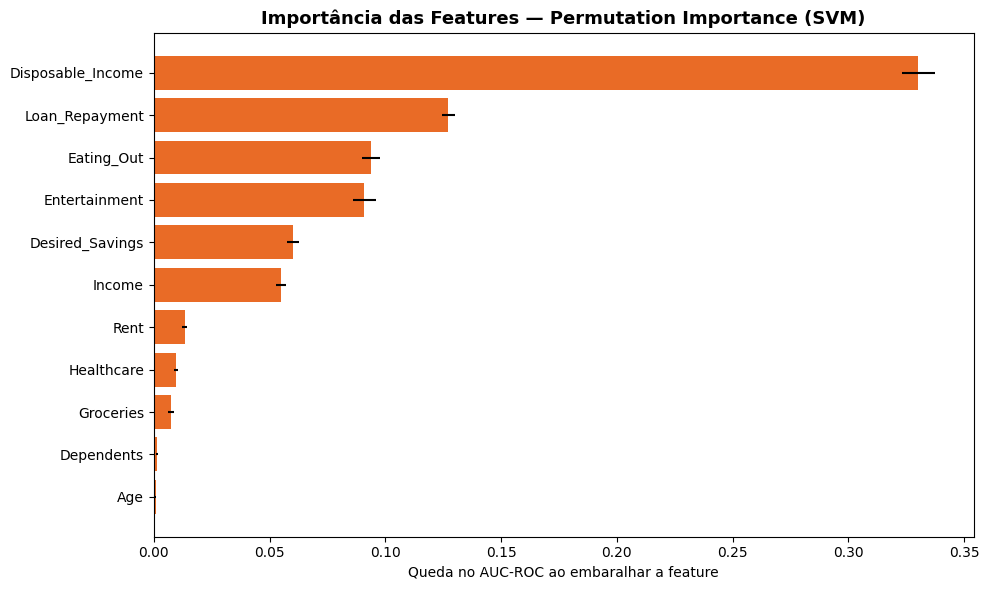

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    svm, X_test_scaled, y_test,
    n_repeats=10, random_state=42, scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'feature': features_reduzidas,
    'importancia': result.importances_mean,
    'std': result.importances_std
}).sort_values('importancia', ascending=True)

print(perm_df.sort_values('importancia', ascending=False).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_df['feature'], perm_df['importancia'],
        xerr=perm_df['std'], color='#e65100', alpha=0.85)
ax.set_title('Importância das Features — Permutation Importance (SVM)', fontweight='bold', fontsize=13)
ax.set_xlabel('Queda no AUC-ROC ao embaralhar a feature')
plt.tight_layout()
plt.savefig('permutation_importance_svm.png', dpi=150)
plt.show()


## 8. Segmentação de Risco

Comparação com João:

| Nível | RF João | SVM |
|---|---|---|
| Baixo | 15.271 (76.8%) | 14.627 (73.5%) |
| **Médio** | **309 (1.6%)** | **1.312 (6.6%)** |
| Alto | 4.308 (21.7%) | 3.949 (19.9%) |

SVM colocou muito mais clientes no risco Médio — mais cauteloso, prefere monitorar em vez de ignorar casos duvidosos.

In [ ]:
X_completo = df[features_reduzidas]
X_completo_scaled = scaler.transform(X_completo)
df['probabilidade_risco'] = svm.predict_proba(X_completo_scaled)[:, 1]

def classificar_risco(prob):
    if prob < 0.30:
        return 'Baixo'
    elif prob < 0.60:
        return 'Médio'
    else:
        return 'Alto'

df['nivel_risco'] = df['probabilidade_risco'].apply(classificar_risco)

segmentacao = df.groupby('nivel_risco').agg(
    clientes=('Income', 'count'),
    renda_media=('Income', 'mean'),
    emprestimo_medio=('Loan_Repayment', 'mean'),
    prob_media=('probabilidade_risco', 'mean')
).reindex(['Baixo', 'Médio', 'Alto'])

segmentacao['pct_base'] = (segmentacao['clientes'] / len(df) * 100).round(1)
segmentacao['exposicao_mensal'] = segmentacao['clientes'] * segmentacao['emprestimo_medio']

print('=' * 65)
print('  SEGMENTAÇÃO DE CLIENTES POR NÍVEL DE RISCO — SVM')
print('=' * 65)
for nivel in ['Baixo', 'Médio', 'Alto']:
    row = segmentacao.loc[nivel]
    print(f"\nRisco {nivel}:")
    print(f"   Clientes:            {int(row['clientes']):,}")
    print(f"   % da base:           {row['pct_base']}%")
    print(f"   Prob. média:         {row['prob_media']*100:.1f}%")
    print(f"   Empréstimo médio:    R$ {row['emprestimo_medio']:,.0f}")
    print(f"   Exposição mensal:    R$ {row['exposicao_mensal']:,.0f}")


  SEGMENTAÇÃO DE CLIENTES POR NÍVEL DE RISCO — SVM

Risco Baixo:
   Clientes:            14,627
   % da base:           73.5%
   Prob. média:         3.3%
   Empréstimo médio:    R$ 603
   Exposição mensal:    R$ 8,826,115

Risco Médio:
   Clientes:            1,312
   % da base:           6.6%
   Prob. média:         44.3%
   Empréstimo médio:    R$ 2,948
   Exposição mensal:    R$ 3,867,532

Risco Alto:
   Clientes:            3,949
   % da base:           19.9%
   Prob. média:         88.0%
   Empréstimo médio:    R$ 6,928
   Exposição mensal:    R$ 27,357,195


## 9. Teste Adicional — CatBoost

Após implementar e avaliar o SVM, decidimos testar um terceiro algoritmo: o **CatBoost** (Categorical Boosting), desenvolvido pela Yandex. 
A motivação foi verificar se um algoritmo baseado em boosting conseguiria superar o SVM, especialmente no AUC-ROC, sem abrir mão do Recall que o SVM entrega tão bem.

### O que é o CatBoost?

O CatBoost é um algoritmo de **gradient boosting** — ele constrói várias árvores de decisão em sequência, onde cada nova árvore tenta corrigir os erros da anterior. 
O nome vem de "Categorical Boosting", pois foi criado para lidar bem com variáveis categóricas, mas performa excelente também com dados numéricos como o nosso.

Diferente do SVM, o CatBoost **não precisa de normalização** dos dados (sem StandardScaler) — ele já lida internamente com as diferenças de escala entre as features.

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


### 9.1 CatBoost v1 — Parâmetros Padrão

Primeiro treinamos o CatBoost com configurações base para estabelecer uma linha de referência:

-  → número de árvores construídas em sequência
-  → o quanto cada nova árvore corrige a anterior (menor = aprende mais devagar, mas mais estável)
-  → profundidade máxima de cada árvore
-  → exibe o progresso a cada 100 iterações

Note que **não usamos**  (dados normalizados) — o CatBoost recebe  diretamente, pois lida com escala internamente.

In [ ]:
modelo_catboost = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    verbose=100
)

modelo_catboost.fit(X_train, y_train)


0:	learn: 0.5915718	total: 116ms	remaining: 57.8s
100:	learn: 0.1559497	total: 2.92s	remaining: 11.5s
200:	learn: 0.1177539	total: 5.99s	remaining: 8.91s
300:	learn: 0.0969387	total: 9.1s	remaining: 6.02s
400:	learn: 0.0813807	total: 11.7s	remaining: 2.89s
499:	learn: 0.0698951	total: 14.3s	remaining: 0us


CatBoostClassifier(depth=6, iterations=500, learning_rate=0.1, verbose=100)

In [41]:
y_pred = modelo_catboost.predict(X_test)
y_prob = modelo_catboost.predict_proba(X_test)[:, 1]

print("|-CatBoost-|")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))


|-CatBoost-|
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      3072
           1       0.90      0.82      0.86       906

    accuracy                           0.94      3978
   macro avg       0.93      0.90      0.91      3978
weighted avg       0.94      0.94      0.94      3978

AUC-ROC: 0.9774

Matriz de Confusão:
[[2992   80]
 [ 165  741]]


### Análise do CatBoost v1

O CatBoost v1 superou o SVM em acurácia (94% vs 91%) e AUC-ROC (0,9774 vs 0,9658), 
mas apresentou Recall menor para vulneráveis: **82% contra 91% do SVM**.

Isso significa que o CatBoost v1 deixou passar **165 clientes vulneráveis** sem detectar, contra apenas 84 do SVM. 
Como não detectar um vulnerável é o erro mais grave neste contexto, decidimos ajustar o modelo.

### 9.2 CatBoost v2 — Ajuste para Desbalanceamento de Classes

O dataset tem 77% de clientes seguros e apenas 23% vulneráveis — um desbalanceamento que faz o modelo tender a prever mais a classe majoritária.

Para corrigir isso, adicionamos o parâmetro , que instrui o modelo a dar **3x mais peso** para cada cliente vulnerável durante o treino. 
É o equivalente ao  que usamos no SVM — ambos forçam o modelo a prestar mais atenção na classe minoritária.

In [44]:
modelo_catboost_v2 = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    scale_pos_weight=3,
    verbose=100
)

modelo_catboost_v2.fit(X_train, y_train)


0:	learn: 0.6121427	total: 173ms	remaining: 1m 26s
100:	learn: 0.1978242	total: 7.78s	remaining: 30.7s
200:	learn: 0.1455386	total: 13.1s	remaining: 19.5s
300:	learn: 0.1127821	total: 17.8s	remaining: 11.8s
400:	learn: 0.0922632	total: 23.2s	remaining: 5.73s
499:	learn: 0.0762624	total: 26s	remaining: 0us


CatBoostClassifier(depth=6, iterations=500, learning_rate=0.1, scale_pos_weight=3, verbose=100)

O scale_pos_weight=3 diz ao modelo: "trate cada cliente vulnerável como se fossem 3 clientes".

In [45]:
y_pred_v2 = modelo_catboost_v2.predict(X_test)
y_prob_v2 = modelo_catboost_v2.predict_proba(X_test)[:, 1]

print("=== CatBoost v2 (scale_pos_weight=3) ===")
print(classification_report(y_test, y_pred_v2))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_v2):.4f}")
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_v2))


=== CatBoost v2 (scale_pos_weight=3) ===
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      3072
           1       0.85      0.88      0.86       906

    accuracy                           0.94      3978
   macro avg       0.91      0.92      0.91      3978
weighted avg       0.94      0.94      0.94      3978

AUC-ROC: 0.9780

Matriz de Confusão:
[[2927  145]
 [ 109  797]]


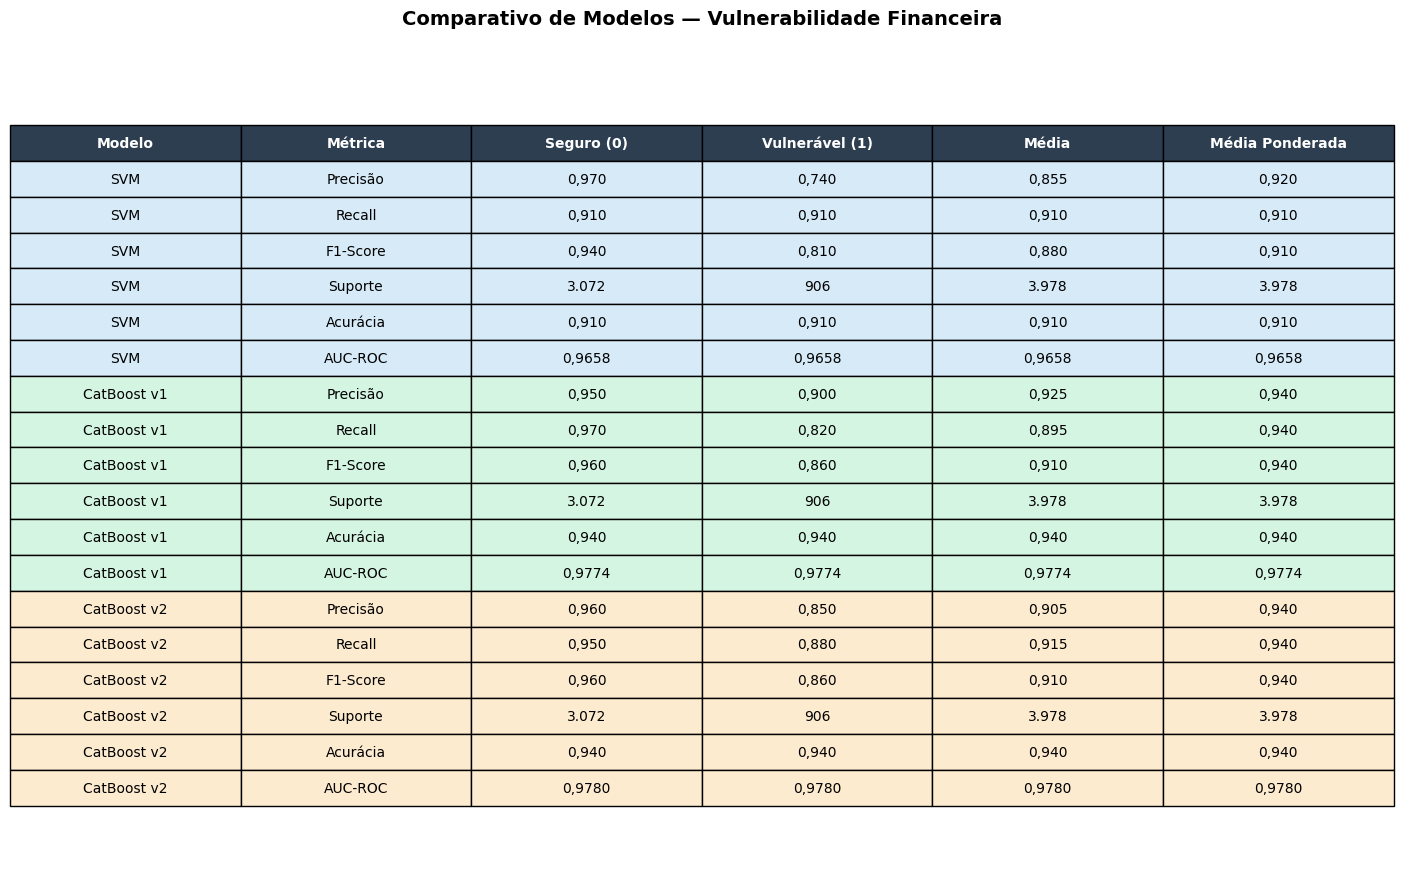

In [47]:
import matplotlib.pyplot as plt

linhas = [
    # SVM
    ('SVM', 'Precisão',  '0,970', '0,740', '0,855', '0,920'),
    ('SVM', 'Recall',    '0,910', '0,910', '0,910', '0,910'),
    ('SVM', 'F1-Score',  '0,940', '0,810', '0,880', '0,910'),
    ('SVM', 'Suporte',   '3.072', '906',   '3.978', '3.978'),
    ('SVM', 'Acurácia',  '0,910', '0,910', '0,910', '0,910'),
    ('SVM', 'AUC-ROC',   '0,9658','0,9658','0,9658','0,9658'),
    # CatBoost v1
    ('CatBoost v1', 'Precisão',  '0,950', '0,900', '0,925', '0,940'),
    ('CatBoost v1', 'Recall',    '0,970', '0,820', '0,895', '0,940'),
    ('CatBoost v1', 'F1-Score',  '0,960', '0,860', '0,910', '0,940'),
    ('CatBoost v1', 'Suporte',   '3.072', '906',   '3.978', '3.978'),
    ('CatBoost v1', 'Acurácia',  '0,940', '0,940', '0,940', '0,940'),
    ('CatBoost v1', 'AUC-ROC',   '0,9774','0,9774','0,9774','0,9774'),
    # CatBoost v2
    ('CatBoost v2', 'Precisão',  '0,960', '0,850', '0,905', '0,940'),
    ('CatBoost v2', 'Recall',    '0,950', '0,880', '0,915', '0,940'),
    ('CatBoost v2', 'F1-Score',  '0,960', '0,860', '0,910', '0,940'),
    ('CatBoost v2', 'Suporte',   '3.072', '906',   '3.978', '3.978'),
    ('CatBoost v2', 'Acurácia',  '0,940', '0,940', '0,940', '0,940'),
    ('CatBoost v2', 'AUC-ROC',   '0,9780','0,9780','0,9780','0,9780'),
]

colunas = ['Modelo', 'Métrica', 'Seguro (0)', 'Vulnerável (1)', 'Média', 'Média Ponderada']
cores = {'SVM': '#D6EAF8', 'CatBoost v1': '#D5F5E3', 'CatBoost v2': '#FDEBD0'}

fig, ax = plt.subplots(figsize=(14, 9))
ax.axis('off')

tabela = ax.table(cellText=linhas, colLabels=colunas, loc='center', cellLoc='center')
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.8)

for (row, col), cell in tabela.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        modelo = linhas[row - 1][0]
        cell.set_facecolor(cores.get(modelo, 'white'))

plt.title('Comparativo de Modelos — Vulnerabilidade Financeira', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('comparativo_modelos.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
import joblib

joblib.dump(modelo_catboost_v2, 'modelo_catboost_vulnerabilidade.pkl')

print("Modelo CatBoost v2 salvo: modelo_catboost_vulnerabilidade.pkl")


## 10. Conclusão Final

| Critério | Random Forest (João) | SVM | CatBoost v1 | CatBoost v2 |
|---|---|---|---|---|
| AUC-ROC | 0,9724 | 0,9658 | 0,9774 | **0,9780** |
| Acurácia | 94% | 91% | 94% | 94% |
| Recall (Vulnerável) | 80% | **91%** | 82% | 88% |
| Precisão (Vulnerável) | 92% | 74% | 90% | 85% |
| Falsos Negativos | 184 | **84** | 165 | 109 |

O **CatBoost v2** apresentou o melhor AUC-ROC geral (0,9780), superando inclusive o Random Forest do modelo de referência. 
Porém, para o contexto deste problema — identificar clientes em vulnerabilidade financeira — o erro mais grave é **não detectar um cliente vulnerável** (falso negativo). 
Nesse critério, o **SVM ainda lidera**, com apenas 84 falsos negativos contra 109 do CatBoost v2.

Cada modelo carrega um trade-off claro:
- **SVM:** detecta mais vulneráveis, mas gera mais alarmes falsos (290 falsos positivos)
- **CatBoost v2:** AUC-ROC superior e mais preciso no geral, mas deixa passar mais vulneráveis

Para uma aplicação real em instituição financeira, o **SVM seria a escolha mais conservadora e segura**. 
O CatBoost v2 seria mais adequado caso o custo operacional de atender falsos positivos fosse alto demais.

In [48]:
import joblib

joblib.dump(modelo_catboost_v2, 'modelo_vulnerabilidade.pkl')

print("Modelo CatBoost v2 salvo: modelo_vulnerabilidade.pkl")


Modelo CatBoost v2 salvo: modelo_vulnerabilidade.pkl
